# 10. End-to-end proof of concept

Single clean run demonstrating the full pipeline:

1. Load shared functions
2. Load raw strip data
3. DBSCAN noise QC (with size filter)
4. Manual cluster review & cleanup (size threshold + FOV-strip exclusion)
5. Save cleaned parquet
6. Window setup (concave hull per strip)
7. LR panel loading & pair selection
8. Analysis parameters
9. Positive-control test run (KRT8 × KRT18)
10. HPC export checklist

**Run sequentially top-to-bottom.** The config cells in sections 4 and 7 are the only ones that may need editing between runs.

### Pipeline overview

```
  raw parquet
      │
      ▼
  [1]  coordinate rotation  (PCA auto or manual angle)
      │
      ▼
  [2]  DBSCAN noise QC                ──►  flag  is_noise
      │
      ▼
  [3]  cluster overview  +  manual cluster exclusions   ← edit if needed
      │
      ▼
  [4]  GMM strip assignment  +  boundary overrides      ← edit if needed
      │
      ▼
  [6]  window per strip          ──►  rect / convex / concave / custom
      │
      ▼
  [7]  LR panel filtering        ──►  viable gene pairs per strip
      │
      ▼
  [8]  r_vals  (dense low-r + coarse tail)
      │
      ▼
  [9]  bivariate K → L(r)  +  permutation envelope  (positive control)
      │
      ▼
  [10] HPC batch export
```

Sections marked **← edit if needed** expose the manual-QC knobs.

## 0: Load shared functions

In [80]:
%run 00_functions.ipynb
print('Functions loaded.')

Functions loaded.


## 1: Load raw data and rotate coordinates

Load the transcript parquet (strip labels from the original GMM are present but will be replaced). Rotate coordinates so the cross-strip axis aligns with `x_rot_px`, then re-run GMM strip assignment per-FOV.

In [64]:
DATA_RAW = '../data/processed/s1_expanded_strips.parquet'

df_raw = pd.read_parquet(DATA_RAW)
print(f'Transcripts loaded: {len(df_raw):,}')
print(f'FOVs: {sorted(df_raw["fov"].unique())}')
print(f'Strips: {sorted(df_raw["strip"].unique())}')
print(f'Columns: {df_raw.columns.tolist()}')

Transcripts loaded: 702,873
FOVs: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Strips: ['strip_1', 'strip_2', 'strip_3']
Columns: ['x', 'y', 'target', 'cell_ID', 'z_raw', 'cell', 'x_global_px', 'fov', 'y_global_px', 'CellComp', 'y_global_px_transformed', 'x_global_px_transformed', 'strip']


### 1a: Coordinate rotation

`TISSUE_ANGLE_DEG = None` → PCA auto-detects the rotation angle.  
Set an explicit value (e.g. `30.0`) to override if PCA misfires.

PCA auto-detected rotation: 6.4 deg anticlockwise


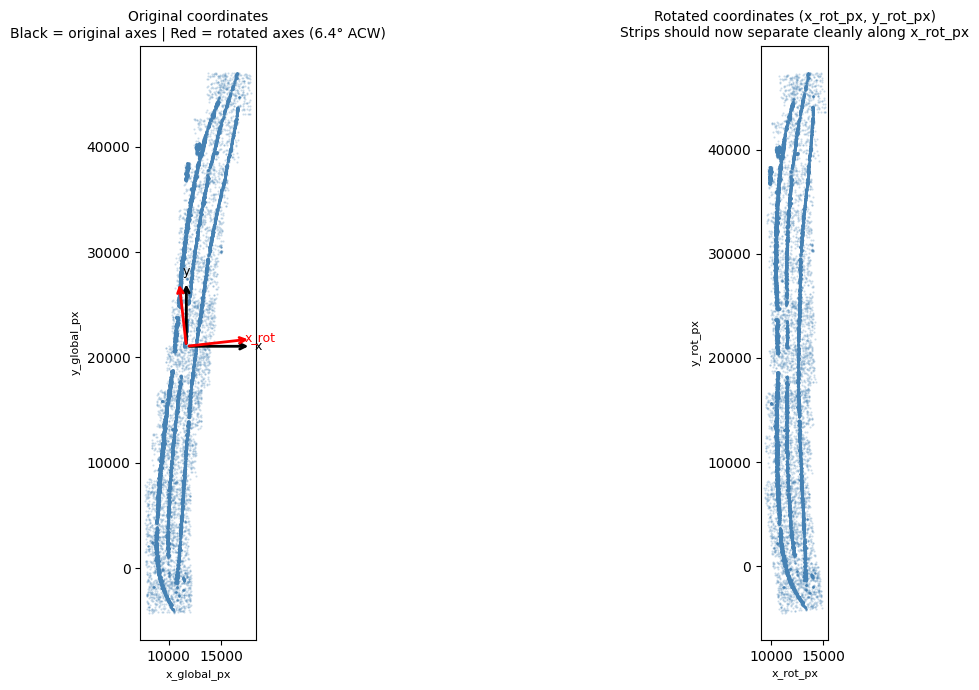

In [65]:
TISSUE_ANGLE_DEG = None   # None = PCA auto-detect | or e.g. 30.0

df_raw = add_rotated_coords(df_raw, tissue_angle_deg=TISSUE_ANGLE_DEG)

## 2: DBSCAN noise QC  *(per FOV, before strip assignment)*

Adaptive DBSCAN grouped **by FOV only**, no strip labels needed yet. Flags diffuse noise (`is_noise`) and small artefact clusters (`is_small_cluster`). Strip assignment runs afterwards on the cleaned data.

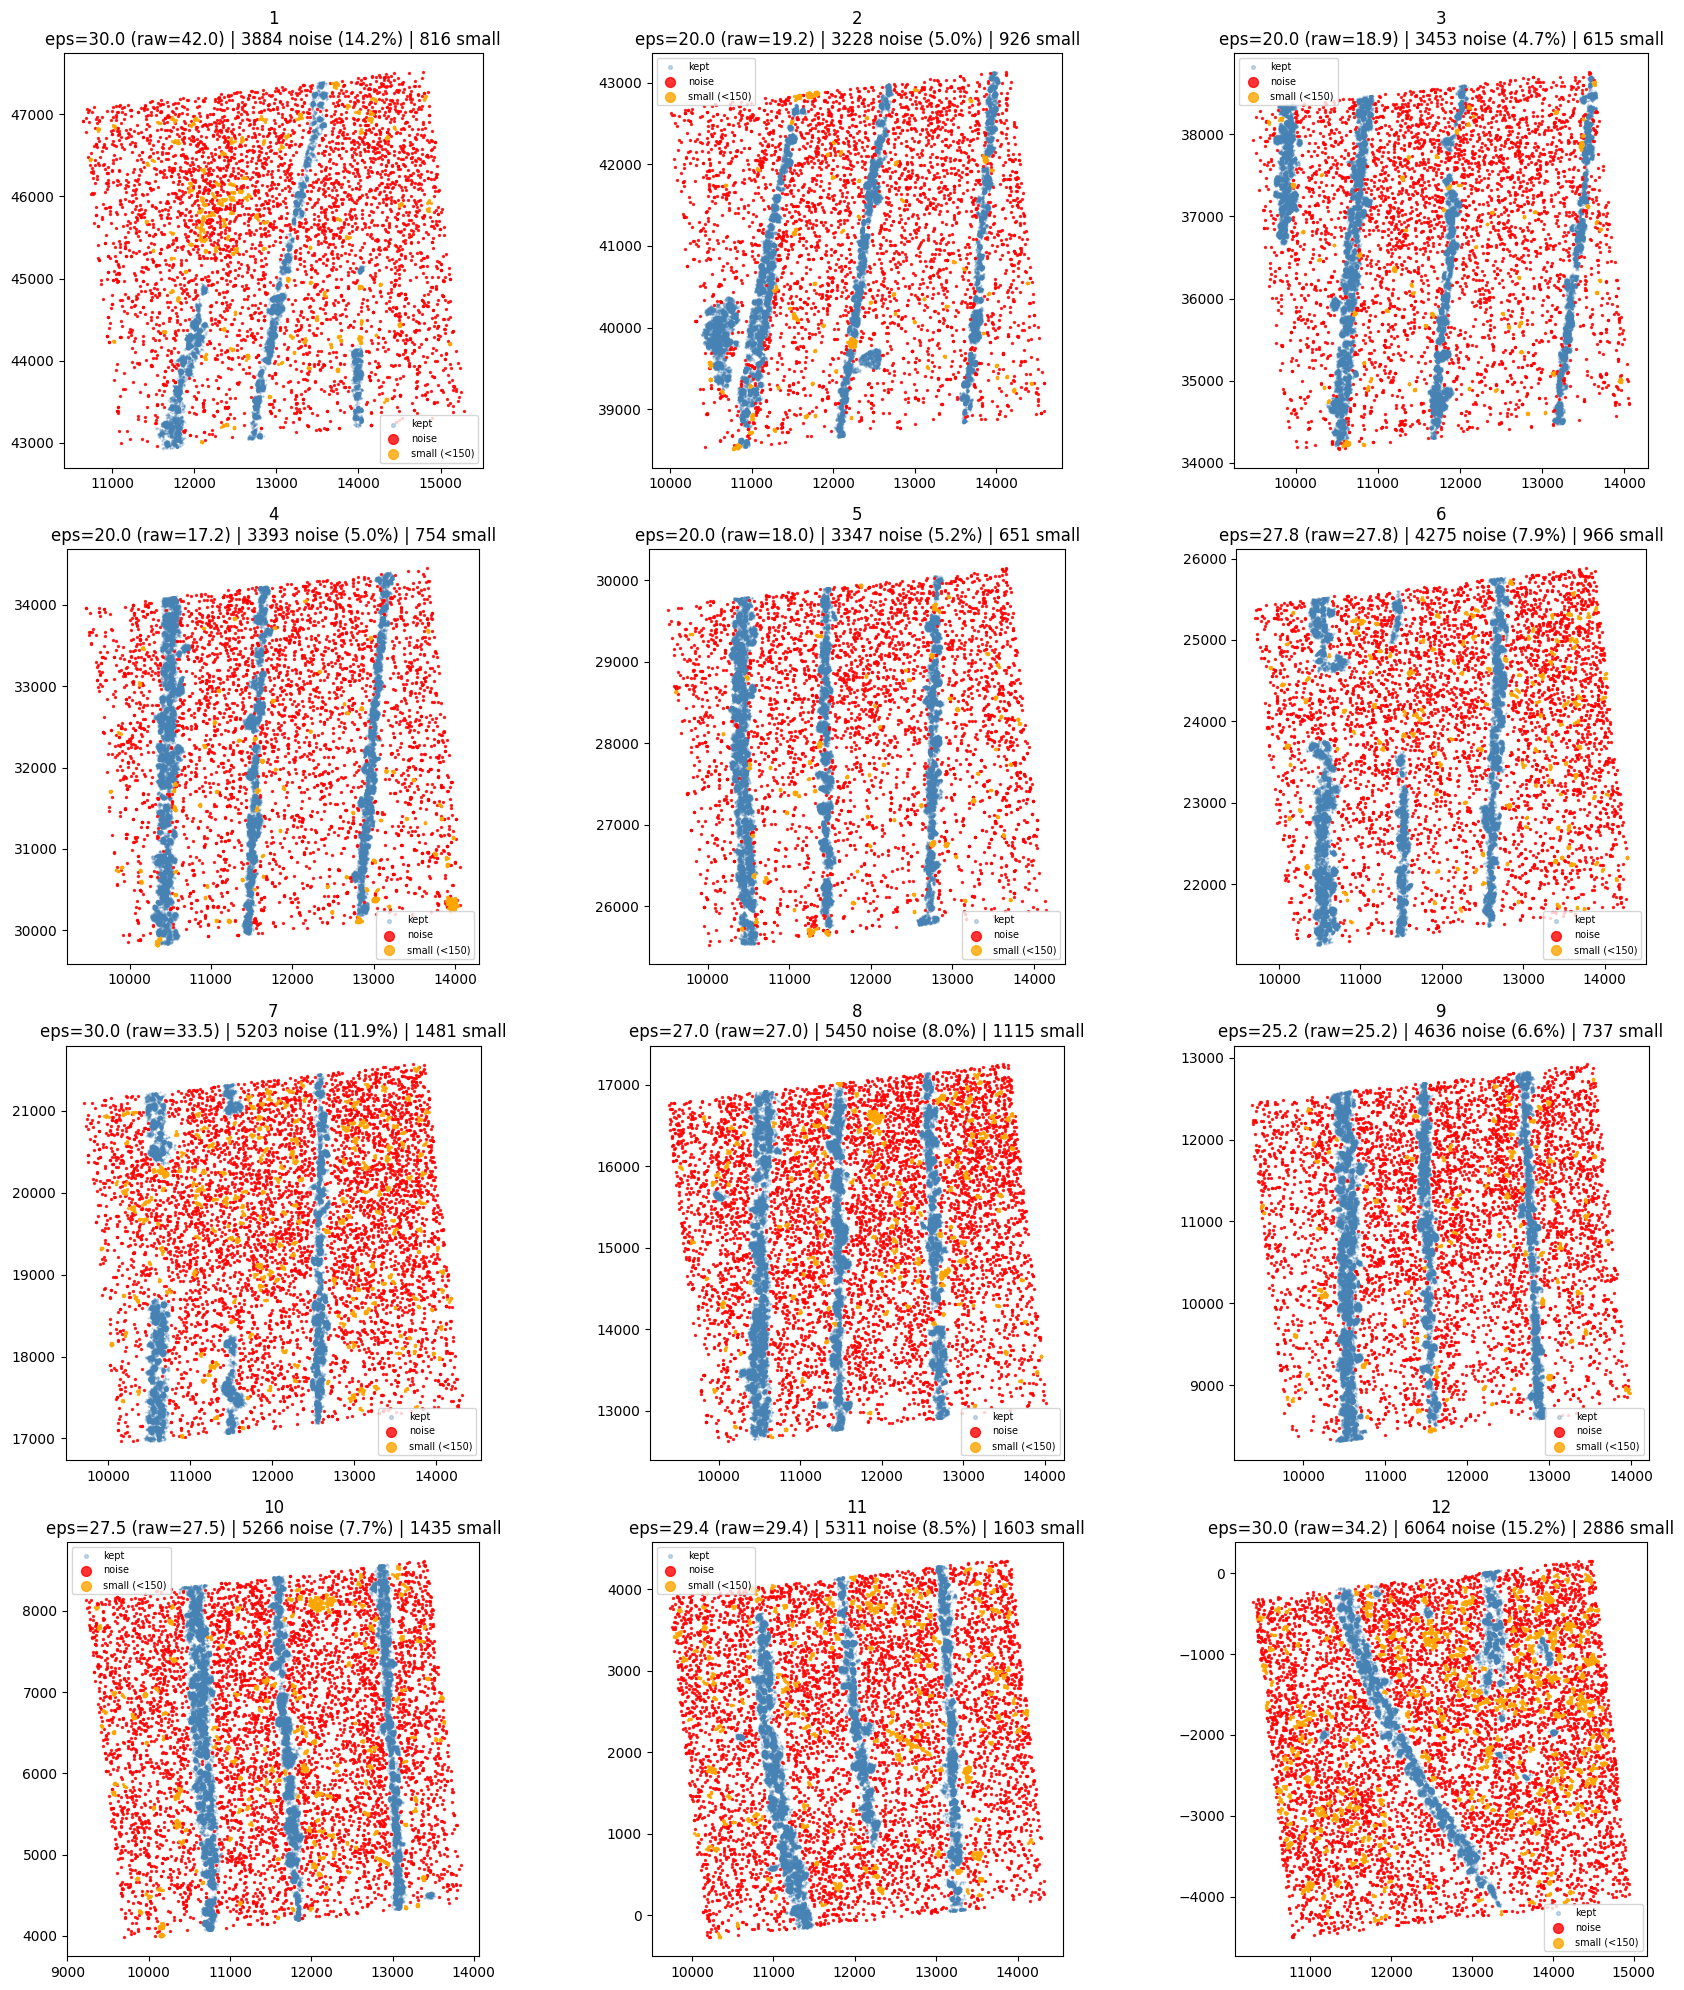

group  n_total  n_noise  n_small_cluster  pct_noise  eps_raw  eps_used
    1    27425     3884              816       14.2     42.0      30.0
    2    64875     3228              926        5.0     19.2      20.0
    3    72701     3453              615        4.7     18.9      20.0
    4    67413     3393              754        5.0     17.2      20.0
    5    63870     3347              651        5.2     18.0      20.0
    6    54138     4275              966        7.9     27.8      27.8
    7    43673     5203             1481       11.9     33.5      30.0
    8    68298     5450             1115        8.0     27.0      27.0
    9    69751     4636              737        6.6     25.2      25.2
   10    68646     5266             1435        7.7     27.5      27.5
   11    62260     5311             1603        8.5     29.4      29.4
   12    39823     6064             2886       15.2     34.2      30.0

QC summary:
  is_noise:         53,510
  is_small_cluster: 13,985
  Passing 

In [66]:
MIN_CLUSTER_SIZE = 150

df_flagged = dbscan_noise_filter(
    df_raw,
    x_col='x_rot_px',
    y_col='y_rot_px',
    group_cols=['fov'],
    min_cluster_size=MIN_CLUSTER_SIZE,
    diagnostics=True,
)

print(f'\nQC summary:')
print(f'  is_noise:         {df_flagged["is_noise"].sum():,}')
print(f'  is_small_cluster: {df_flagged["is_small_cluster"].sum():,}')
print(f'  Passing both:     {(~df_flagged["is_noise"] & ~df_flagged["is_small_cluster"]).sum():,}')

## 3: Cluster overview and manual cleanup

Per-FOV scatter coloured by cluster quality. **Blue** = kept, **Orange** = small cluster (auto-excluded), **Grey** = noise.

Use `ALSO_EXCLUDE` to manually remove specific cluster IDs (read from the table below the plot).

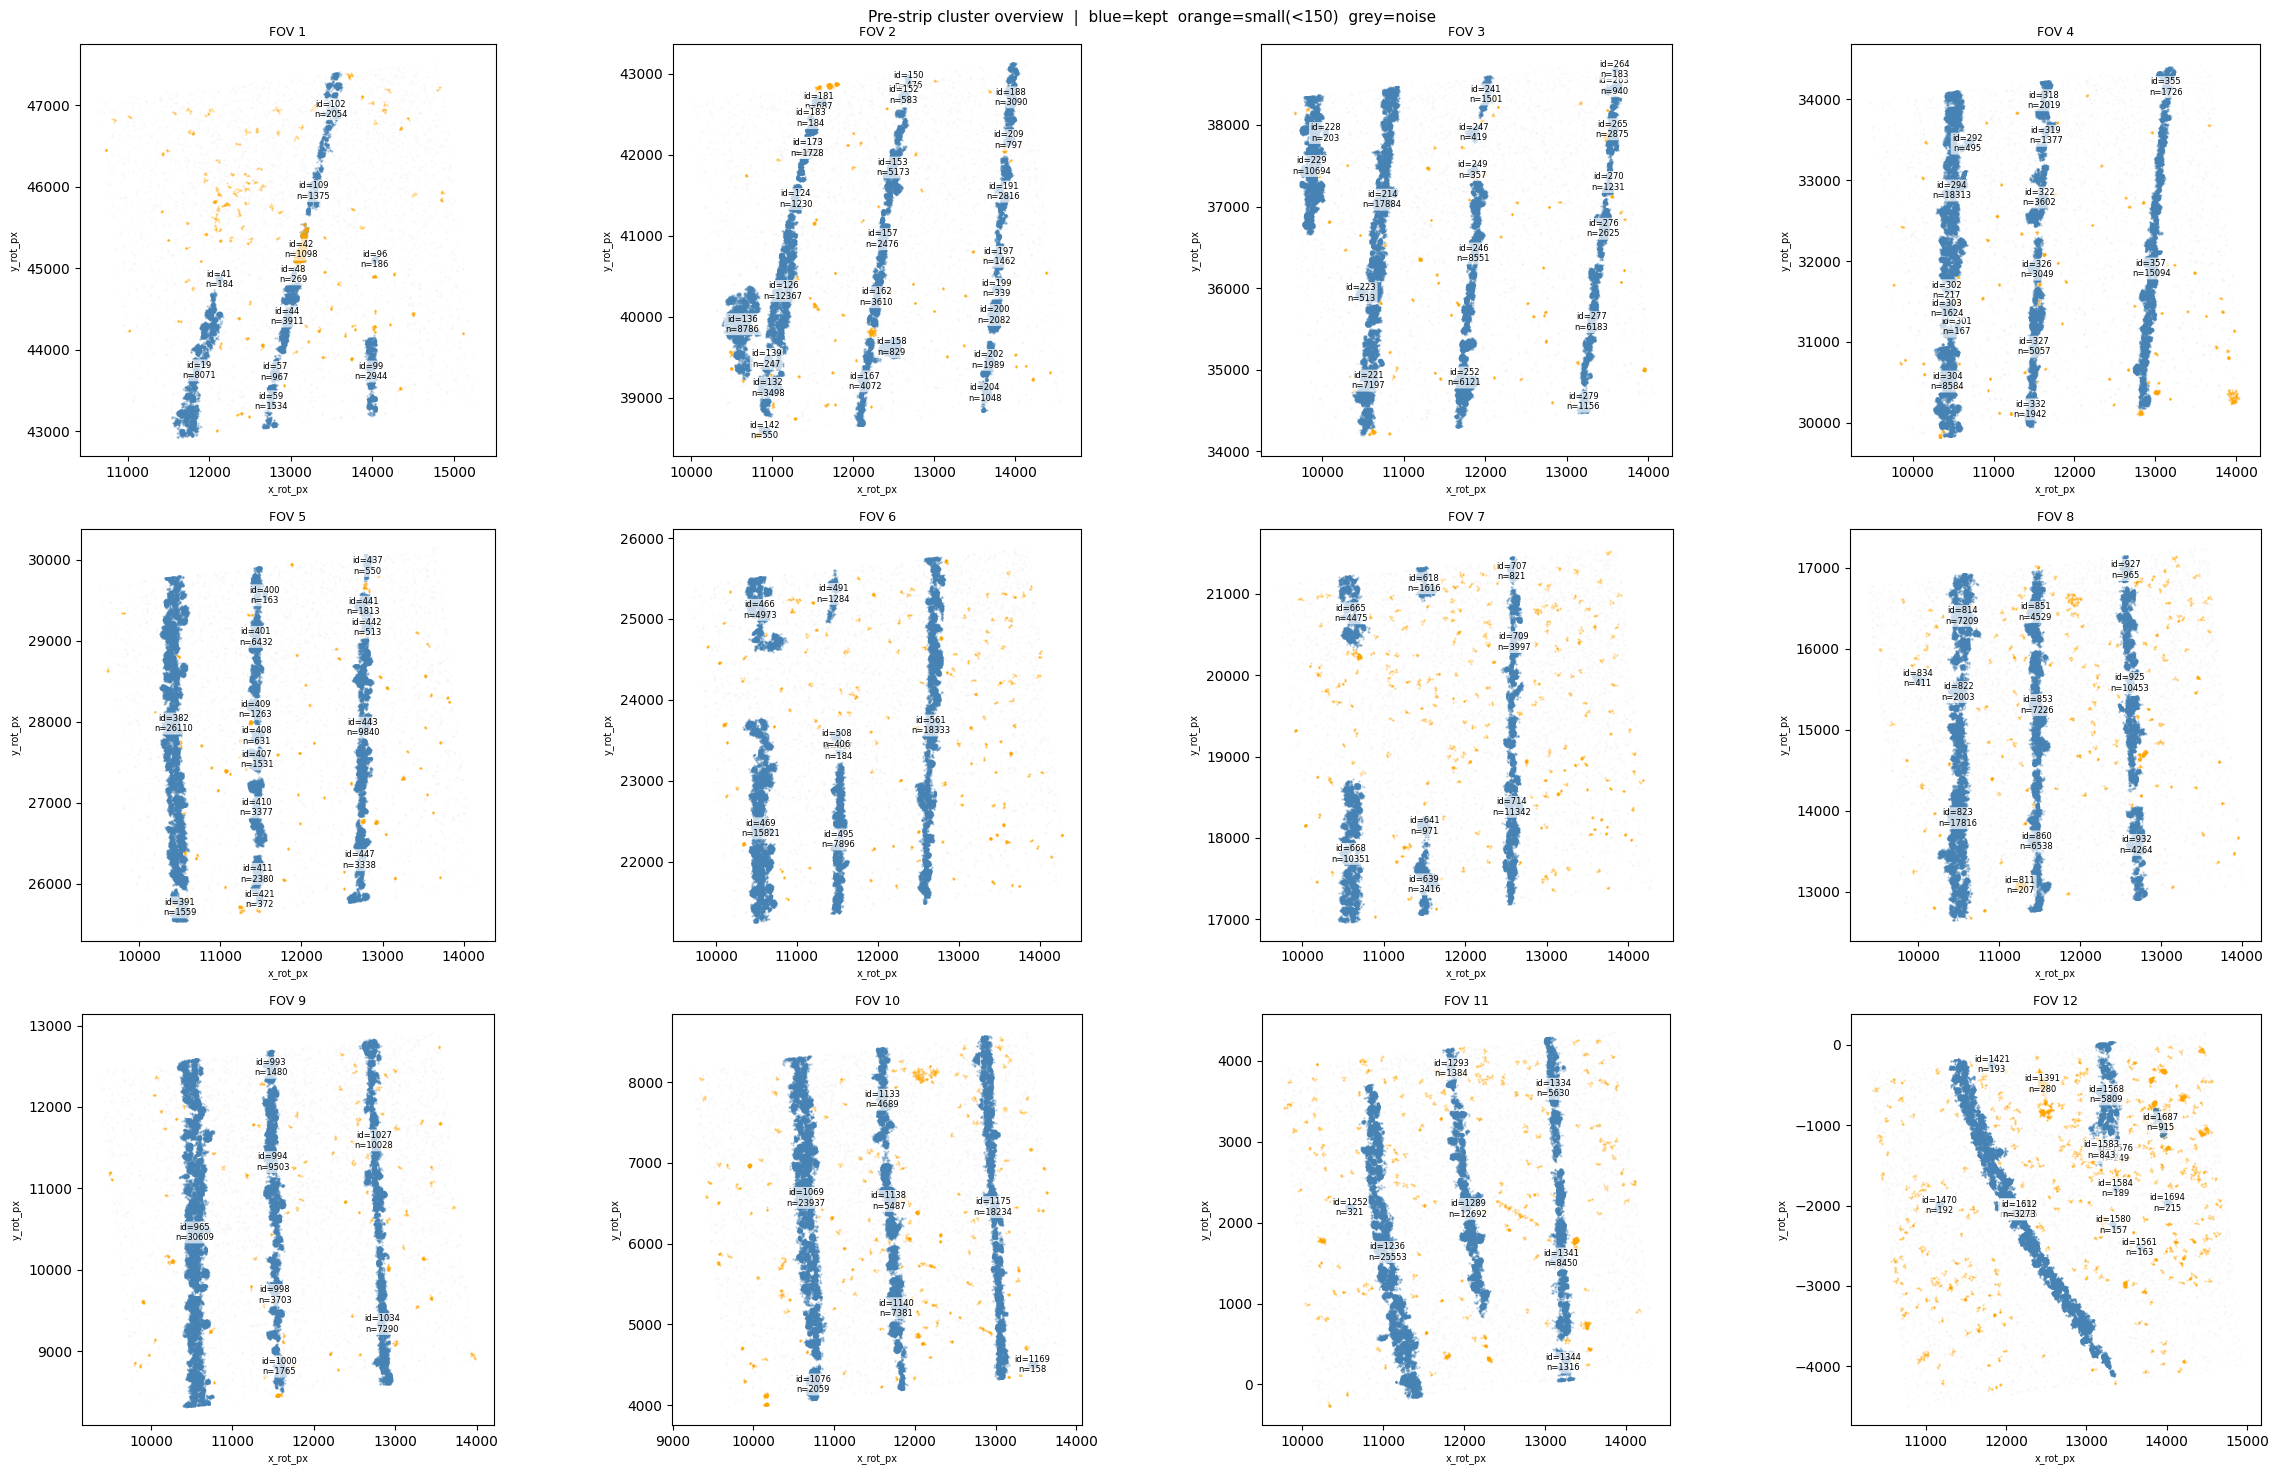

 global_id  fov   strip  dbscan_label  n_transcripts  small?
         0    1 strip_1            73              9    True
         1    1 strip_1            74             10    True
         2    1 strip_1            75              7    True
         3    1 strip_1            76              6    True
         4    1 strip_1            77              5    True
         5    1 strip_1            78              5    True
         6    1 strip_1            79             11    True
         7    1 strip_1            80              7    True
         8    1 strip_1            81              9    True
         9    1 strip_1            82              5    True
        10    1 strip_1            83              6    True
        11    1 strip_1            84              5    True
        12    1 strip_1            85              8    True
        13    1 strip_1            86             19    True
        14    1 strip_1            87             14    True
        15    1 strip_1 

In [48]:
cluster_table = build_cluster_table(df_flagged)

plot_fov_overview(
    df_flagged,
    cluster_table,
    min_cluster_size=MIN_CLUSTER_SIZE,
    x_col='x_rot_px',
    y_col='y_rot_px',
)

### Cleanup config  ← **edit if needed**

`MIN_CLUSTER_SIZE`: auto-excludes all clusters smaller than this.  
`ALSO_EXCLUDE`: list of `global_id` values to force-exclude (rare, for obvious single artefacts that survive the size threshold).

In [67]:
MIN_CLUSTER_SIZE = 120
ALSO_EXCLUDE     = [41,96,136,158,228,229,811,834,1169,1252,1421,1470,1391,1687,1694,1561,1580,1584]   # e.g. [12, 47]

df_cleaned = apply_cleanup(
    df_flagged,
    cluster_table,
    MIN_CLUSTER_SIZE,
    also_exclude=ALSO_EXCLUDE,
)

n_clean = (~df_cleaned['is_noise'] & ~df_cleaned['manually_excluded']).sum()
print(f'Transcripts after cleanup: {n_clean:,}')

Transcripts after cleanup: 611,150


## 4: Strip assignment

GMM run per-FOV on `x_rot_px` to assign strip labels. Fitting uses all transcripts (noise flagged but labels still assigned spatially, noise will be excluded from analysis downstream).

**`FOV_N_STRIPS`**, leave empty (`{}`) if every FOV spans all three strips.  
Fill in FOVs that only cover two strips (or one):

```python
FOV_N_STRIPS = {
    4:  ('strip_1', 'strip_2'),   # FOV 4 only has strips 1 & 2
    11: ('strip_2', 'strip_3'),   # FOV 11 only has strips 2 & 3
    7:  ('strip_2',),             # FOV 7 is entirely strip 2
}
```

In [68]:
FOV_N_STRIPS = {
    # fov_id: tuple of strip names present in that FOV
    # Leave empty if all FOVs span all three strips
    # Examples:
       12:  ('strip_1', 'strip_3'),   # only strips 1 & 3
    #   11: ('strip_2', 'strip_3'),   # only strips 2 & 3
    #   7:  ('strip_2',),             # single strip
}

In [69]:
df_cleaned, gmm_boundaries = reassign_strips_gmm(
    df_cleaned,
    x_col='x_rot_px',
    fov_n_strips=FOV_N_STRIPS,
)

Reassigning strips per-FOV on 'x_rot_px' (fitting on 611,150 clean / 702,873 total rows):
  FOV  1: strips=('strip_1', 'strip_2', 'strip_3')  means=[11870, 12994, 13789]  boundaries=[12432, 13391]  strip_1=8,071  strip_2=9,573  strip_3=4,711
  FOV  2: strips=('strip_1', 'strip_2', 'strip_3')  means=[11158, 12349, 13808]  boundaries=[11754, 13078]  strip_1=21,226  strip_2=16,390  strip_3=13,623
  FOV  3: strips=('strip_1', 'strip_2', 'strip_3')  means=[10685, 11828, 13404]  boundaries=[11256, 12616]  strip_1=25,594  strip_2=16,949  strip_3=15,193
  FOV  4: strips=('strip_1', 'strip_2', 'strip_3')  means=[10465, 11543, 12969]  boundaries=[11004, 12256]  strip_1=29,400  strip_2=17,046  strip_3=16,820
  FOV  5: strips=('strip_1', 'strip_2', 'strip_3')  means=[10430, 11444, 12753]  boundaries=[10937, 12098]  strip_1=27,669  strip_2=16,149  strip_3=16,054
  FOV  6: strips=('strip_1', 'strip_2', 'strip_3')  means=[10549, 11504, 12652]  boundaries=[11026, 12078]  strip_1=20,794  strip_2=9,770 

### 4b: Strip assignment diagnostic

Per-FOV scatter + x-histogram in rotated coordinates. **Black** boundary line = clean gap between strips. **Red** boundary line = strips overlap (GMM struggled for that FOV).

Read the boundary x-values off the histograms, then fill in `STRIP_OVERRIDES`.

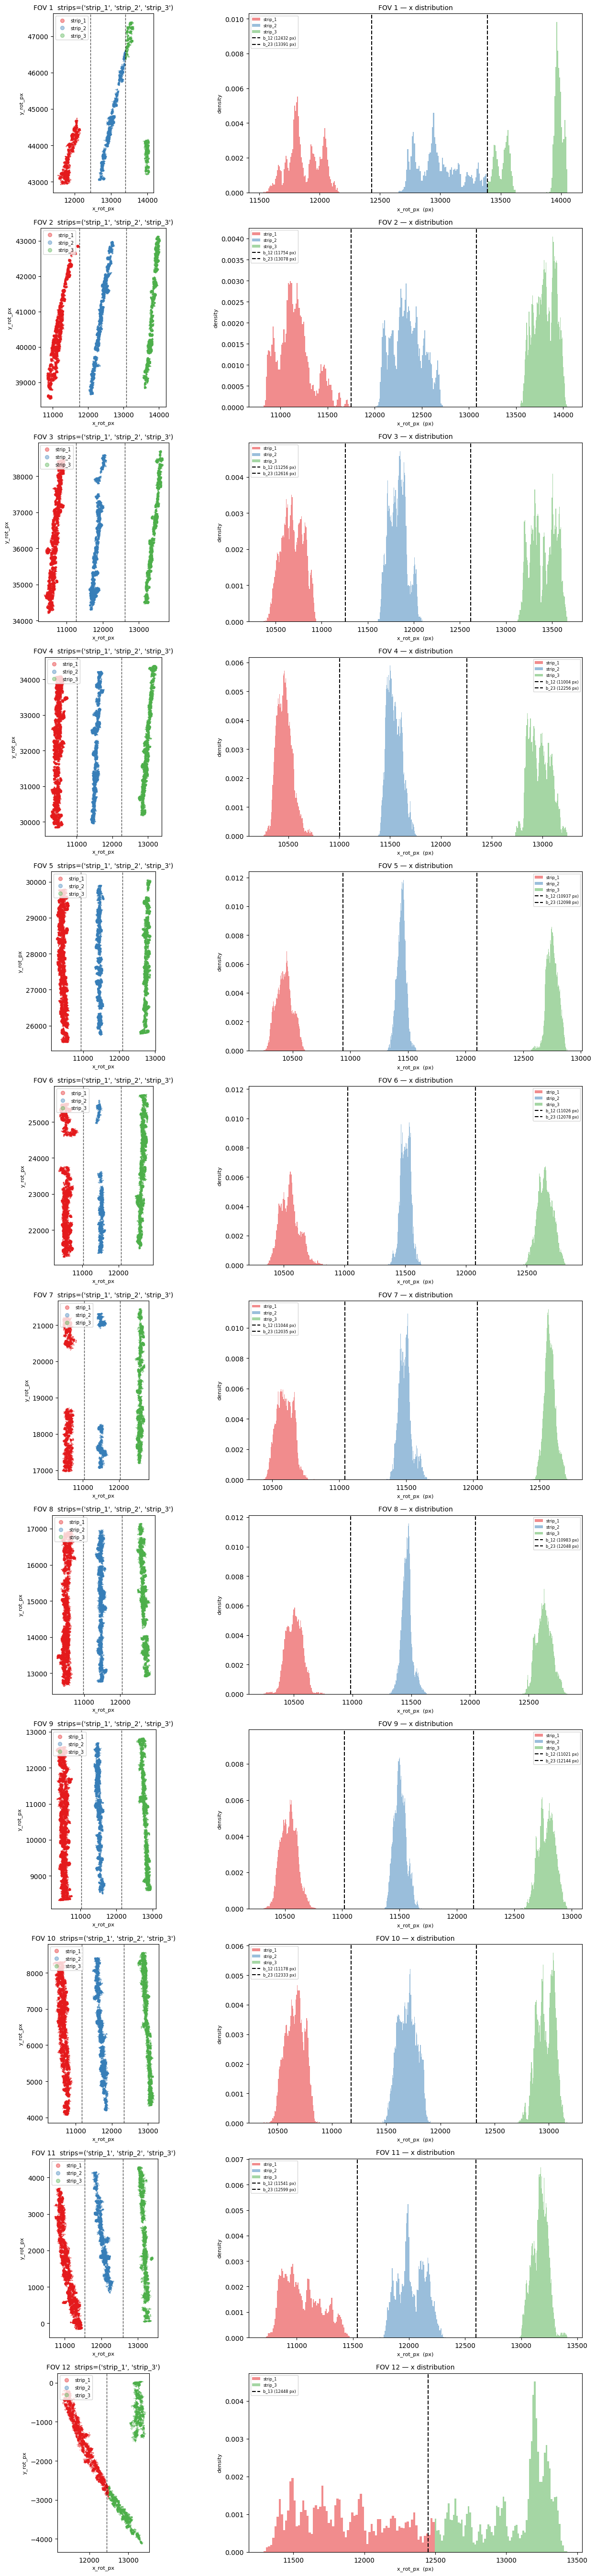


Strip boundary summary (negative gap = strip means reversed / collapsed):
 fov                      strips  gap_12    b_12  gap_23    b_23  gap_13    b_13
   1 (strip_1, strip_2, strip_3)  1122.0 12432.0   813.0 13391.0     NaN     NaN
   2 (strip_1, strip_2, strip_3)  1190.0 11754.0  1459.0 13078.0     NaN     NaN
   3 (strip_1, strip_2, strip_3)  1143.0 11256.0  1577.0 12616.0     NaN     NaN
   4 (strip_1, strip_2, strip_3)  1078.0 11004.0  1426.0 12256.0     NaN     NaN
   5 (strip_1, strip_2, strip_3)  1014.0 10937.0  1309.0 12098.0     NaN     NaN
   6 (strip_1, strip_2, strip_3)   955.0 11026.0  1149.0 12078.0     NaN     NaN
   7 (strip_1, strip_2, strip_3)   900.0 11044.0  1082.0 12035.0     NaN     NaN
   8 (strip_1, strip_2, strip_3)   960.0 10983.0  1169.0 12048.0     NaN     NaN
   9 (strip_1, strip_2, strip_3)   970.0 11021.0  1277.0 12144.0     NaN     NaN
  10 (strip_1, strip_2, strip_3)  1036.0 11178.0  1274.0 12333.0     NaN     NaN
  11 (strip_1, strip_2, strip_3)  

In [70]:
strip_summary = plot_strip_assignments(
    df_cleaned,
    x_col='x_rot_px',
    y_col='y_rot_px',
    boundaries=gmm_boundaries,
    fov_n_strips=FOV_N_STRIPS,
)

### Override config  ← **edit if needed**

Each FOV entry is a **positional list** of boundary values, one per adjacent strip pair declared in `FOV_N_STRIPS[fov]`. List length must equal `len(strips) - 1`.

Boundary values can be mixed:

* `None`, keep the GMM-fitted value for that position
* `number`, vertical cutoff at `x = number`
* `[(x1, y1), (x2, y2)]`, **diagonal line** through two points in rotated coords

```python
FOV_N_STRIPS = {
    12: ('strip_1', 'strip_3'),         # strip_2 absent in this FOV
}

STRIP_OVERRIDES = {
    5:  [11200, 12400],                          # 3-strip: [b12, b23]
    11: [None, [(12700, 0), (13200, -3800)]],    # 3-strip: keep b12, diagonal b23
    12: [[(12700, 0), (13200, -3800)]],          # 2-strip (1,3): single b13
}
```
Read x / y coordinates for line endpoints straight off the scatter panel of the diagnostic above. Leave empty `{}` if all FOVs look correct.

  FOV 1 strips=('strip_1', 'strip_2', 'strip_3'):  vertical x=12431.739247457735  |  vertical x=13650
    Before: {'strip_2': 10823, 'strip_1': 9795, 'strip_3': 6807}
    After:  {'strip_2': 12667, 'strip_1': 9971, 'strip_3': 4787}
  FOV 12 strips=('strip_1', 'strip_3'):  line (12500,0) → (13400,-3500)
    Before: {'strip_3': 20305, 'strip_1': 19518}
    After:  {'strip_1': 27008, 'strip_3': 12815}

Re-plotting overridden FOVs with the applied boundaries:


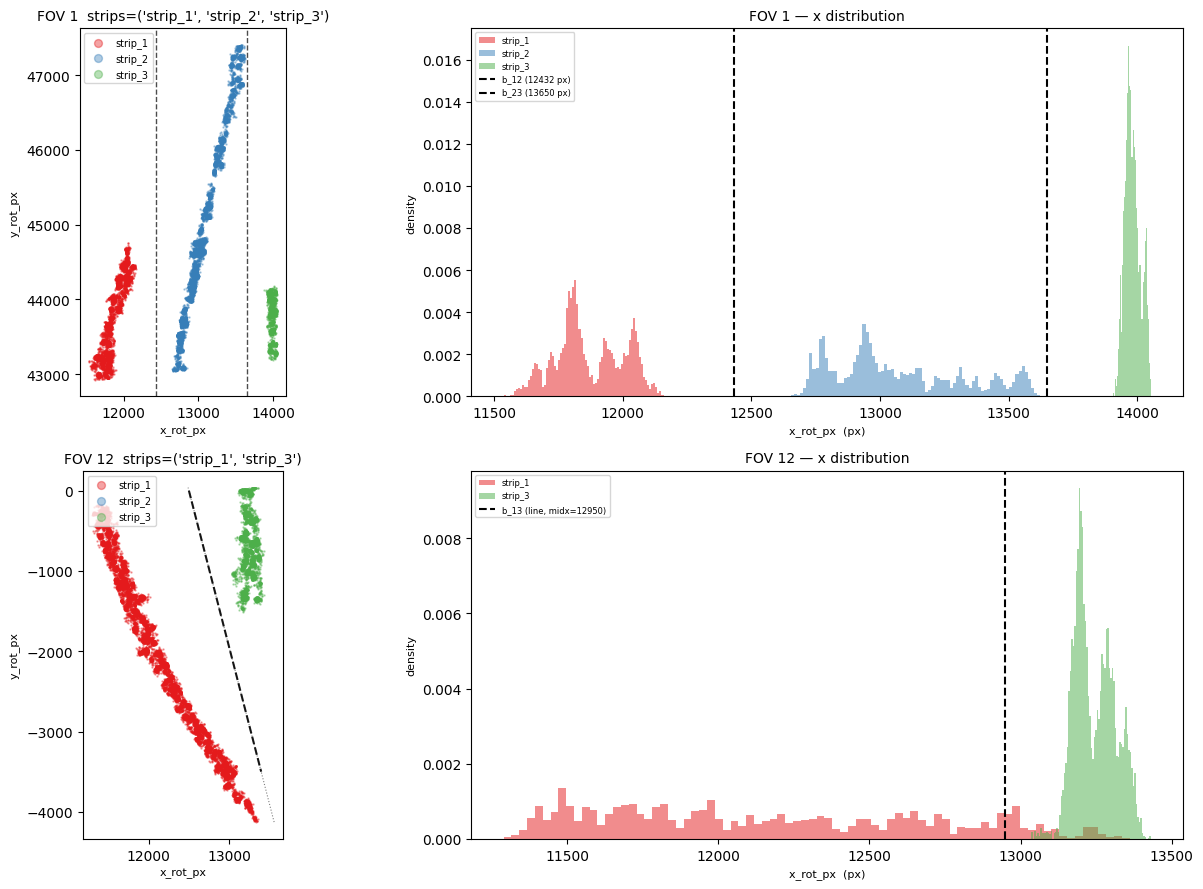


Strip boundary summary (negative gap = strip means reversed / collapsed):
 fov                      strips  gap_12    b_12  gap_23    b_23  gap_13                     b_13
   1 (strip_1, strip_2, strip_3)  1203.0 12432.0   909.0 13650.0     NaN                      NaN
  12          (strip_1, strip_3)     NaN     NaN     NaN     NaN  1087.0 (12500,0)->(13400,-3500)


In [72]:
STRIP_OVERRIDES = {
    # fov_id: [b1, b2, ...]   (positional, aligned with FOV_N_STRIPS[fov] adjacent pairs)
    1: [None, 13650],
    12:[[(12500, 0), (13400, -3500)]]
    # each boundary: None | number (vertical) | [(x1,y1),(x2,y2)] (diagonal line)
}

df_cleaned = apply_strip_overrides(
    df_cleaned, STRIP_OVERRIDES,
    fov_n_strips=FOV_N_STRIPS,
    gmm_boundaries=gmm_boundaries,
    x_col='x_rot_px', y_col='y_rot_px',
)

if STRIP_OVERRIDES:
    print('\nRe-plotting overridden FOVs with the applied boundaries:')
    # Resolve None entries to GMM fallback so the plot shows the actual applied lines
    plot_bounds = {}
    for fov, bvals in STRIP_OVERRIDES.items():
        resolved = list(bvals)
        fallback = gmm_boundaries.get(fov, [])
        for i, v in enumerate(resolved):
            if v is None and i < len(fallback):
                resolved[i] = fallback[i]
        plot_bounds[fov] = resolved

    plot_strip_assignments(
        df_cleaned,
        fovs=list(STRIP_OVERRIDES.keys()),
        x_col='x_rot_px', y_col='y_rot_px',
        boundaries=plot_bounds,
        fov_n_strips=FOV_N_STRIPS,
    )

### 4c: Combined tissue strip overview

Single plot of all FOVs with final strip assignments. Confirms strips make anatomical sense before proceeding to window assignment.

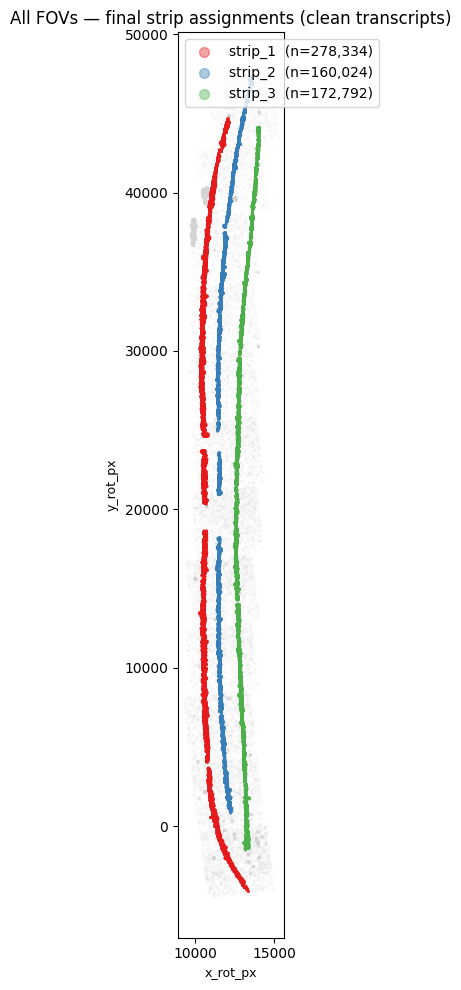

Saved: ../data/processed/s1_all_strips_cleaned.parquet
Columns: ['x', 'y', 'target', 'cell_ID', 'z_raw', 'cell', 'x_global_px', 'fov', 'y_global_px', 'CellComp', 'y_global_px_transformed', 'x_global_px_transformed', 'strip', 'x_rot_px', 'y_rot_px', 'dbscan_label', 'is_noise', 'is_small_cluster', 'eps_used', 'eps_raw', 'manually_excluded']
Clean transcripts for analysis: 611,150
  strip_1: 278,334
  strip_2: 160,024
  strip_3: 172,792


In [73]:
plot_strip_tissue_overview(df_cleaned, x_col='x_rot_px', y_col='y_rot_px')

out_path = '../data/processed/s1_all_strips_cleaned.parquet'
df_cleaned.to_parquet(out_path, index=False)
print(f'Saved: {out_path}')
print(f'Columns: {df_cleaned.columns.tolist()}')

# Working dataframe for window/K-function steps
df_clean = df_cleaned[
    ~df_cleaned['is_noise'] &
    ~df_cleaned['manually_excluded']
].copy()
print(f'Clean transcripts for analysis: {len(df_clean):,}')
for s in ['strip_1', 'strip_2', 'strip_3']:
    print(f'  {s}: {(df_clean["strip"] == s).sum():,}')

## 6: Window setup

One window per strip across all FOVs combined.

**`WINDOW_TYPE = 'concave'`** is the new default. The concave hull (Shapely 2.x, `ratio=0.1`) follows the tissue edge far more tightly than the convex hull for thin curved sections.

> **Methodological note:** A tighter window reduces the area used to estimate λ_B (transcript intensity), which affects absolute K(r) values. However, the permutation envelope is computed with the same window, so the test (observed vs. null) remains valid. The concave hull is strictly more accurate for non-convex tissue shapes.

In [74]:
WINDOW_TYPE    = 'concave'  # 'concave' | 'hull' | 'rect' | 'custom'
CONCAVE_RATIO  = 0.1        # 0 = tightest, 1 = convex hull
CUSTOM_WINDOW_PATHS = {
    # 'strip_1': '../data/processed/custom_window_strip_1.json',
    # 'strip_2': '../data/processed/custom_window_strip_2.json',
    # 'strip_3': '../data/processed/custom_window_strip_3.json',
}

# Clean working dataframe
STRIPS = ['strip_1', 'strip_2', 'strip_3']
strip_dfs = {s: df_clean[df_clean['strip'] == s] for s in STRIPS}
strip_windows = {}

for strip_name in STRIPS:
    custom_path = CUSTOM_WINDOW_PATHS.get(strip_name) if WINDOW_TYPE == 'custom' else None
    strip_windows[strip_name] = get_window(
        strip_dfs[strip_name],
        window_type=WINDOW_TYPE,
        custom_path=custom_path,
        concave_ratio=CONCAVE_RATIO,
    )
    w = strip_windows[strip_name]
    area = w.area if not isinstance(w, tuple) else (w[1]-w[0])*(w[3]-w[2])
    print(f'  {strip_name}: {len(strip_dfs[strip_name]):,} transcripts | '
          f'window area = {area/1e6:.2f} Mpx²')

  strip_1: 278,334 transcripts | window area = 20.39 Mpx²
  strip_2: 160,024 transcripts | window area = 13.69 Mpx²
  strip_3: 172,792 transcripts | window area = 12.70 Mpx²


### 6b: Convex vs concave hull comparison

Dashed black = convex hull. Solid coloured = concave hull. The concave hull area should be substantially smaller for thin curved strips.

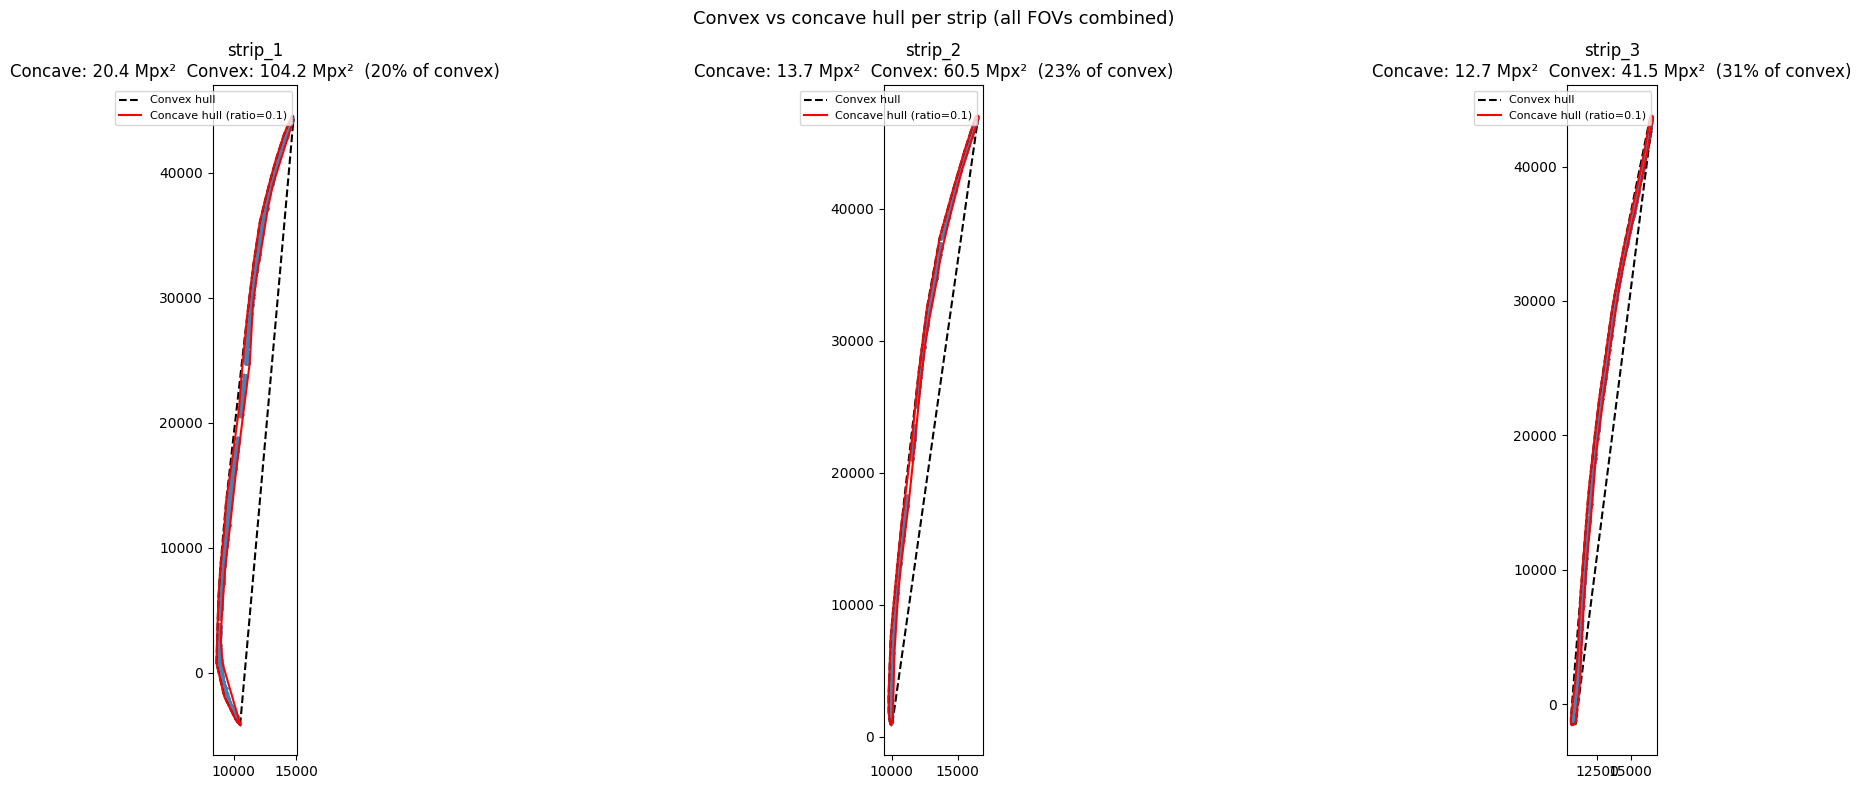

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

for ax, strip_name in zip(axes, STRIPS):
    sdf = strip_dfs[strip_name]
    w_concave = strip_windows[strip_name]
    w_convex  = get_convex_hull(sdf)

    ax.scatter(sdf['x_global_px'], sdf['y_global_px'],
               s=0.1, alpha=0.3, c='steelblue', rasterized=True)

    # Convex hull - dashed black
    cx, cy = w_convex.exterior.xy
    ax.plot(cx, cy, 'k--', lw=1.5, label='Convex hull')

    # Concave hull - solid red
    if not isinstance(w_concave, tuple):
        px, py = w_concave.exterior.xy
        ax.plot(px, py, 'r-', lw=1.5, label=f'Concave hull (ratio={CONCAVE_RATIO})')
        area_concave = w_concave.area
        area_convex  = w_convex.area
        pct = 100 * area_concave / area_convex
        ax.set_title(
            f'{strip_name}\n'
            f'Concave: {area_concave/1e6:.1f} Mpx²  '
            f'Convex: {area_convex/1e6:.1f} Mpx²  '
            f'({pct:.0f}% of convex)'
        )
    ax.legend(fontsize=8)
    ax.set_aspect('equal')

fig.suptitle('Convex vs concave hull per strip (all FOVs combined)', fontsize=13)
plt.tight_layout()
plt.show()

## 7: LR panel & pair selection

In [76]:
lr_index      = load_lr_index('../data/processed/lr_panel_index.json')
genes_in_data = set(df_clean['target'].unique())

print(f'LR pairs in index:       {len(lr_index)}')
print(f'Unique genes in tissue:  {len(genes_in_data)}')

summary = {'strip_1': 0, 'strip_2': 0, 'strip_3': 0, 'any': 0}
for key, strip_data in lr_index.items():
    lig, rec = key.split('|')
    if lig not in genes_in_data or rec not in genes_in_data:
        continue
    any_viable = False
    for s in ['strip_1', 'strip_2', 'strip_3']:
        if strip_data[s]['viable']:
            summary[s] += 1
            any_viable = True
    if any_viable:
        summary['any'] += 1

print(f'\nViable pairs in this tissue:')
for k, v in summary.items():
    print(f'  {k}: {v}')

LR pairs in index:       146
Unique genes in tissue:  1199

Viable pairs in this tissue:
  strip_1: 146
  strip_2: 146
  strip_3: 146
  any: 146


### 7b: Batch configuration  ← **edit if needed**

In [77]:
BATCH_STRIPS = ['strip_1', 'strip_2', 'strip_3']

batch_pairs = query_lr_panel(
    lr_index, genes_present=genes_in_data, strip=None, min_n=50,
)

batch_jobs = []
for lig, rec in batch_pairs:
    key = f'{lig}|{rec}'
    for s in BATCH_STRIPS:
        if lr_index[key][s]['viable']:
            batch_jobs.append((lig, rec, s))

print(f'Unique pairs:  {len(batch_pairs)}')
print(f'Total jobs:    {len(batch_jobs)}  (pairs × viable strips)')
print('\nFirst 15 jobs:')
for lig, rec, s in batch_jobs[:15]:
    key = f'{lig}|{rec}'
    n_a = lr_index[key][s]['ligand_n']
    n_b = lr_index[key][s]['receptor_n']
    print(f'  {lig:15s} × {rec:15s}  {s}  (n_lig={n_a}, n_rec={n_b})')

Unique pairs:  146
Total jobs:    438  (pairs × viable strips)

First 15 jobs:
  DLL1            × NOTCH1           strip_1  (n_lig=165, n_rec=102)
  DLL1            × NOTCH1           strip_2  (n_lig=128, n_rec=76)
  DLL1            × NOTCH1           strip_3  (n_lig=143, n_rec=102)
  IGF1            × IGF1R            strip_1  (n_lig=141, n_rec=101)
  IGF1            × IGF1R            strip_2  (n_lig=78, n_rec=52)
  IGF1            × IGF1R            strip_3  (n_lig=95, n_rec=66)
  JAG1            × NOTCH1           strip_1  (n_lig=107, n_rec=102)
  JAG1            × NOTCH1           strip_2  (n_lig=59, n_rec=76)
  JAG1            × NOTCH1           strip_3  (n_lig=96, n_rec=102)
  CXCL16          × CXCR6            strip_1  (n_lig=172, n_rec=154)
  CXCL16          × CXCR6            strip_2  (n_lig=103, n_rec=88)
  CXCL16          × CXCR6            strip_3  (n_lig=118, n_rec=114)
  IGF2            × IGF2R            strip_1  (n_lig=137, n_rec=189)
  IGF2            × IGF2R        

## 8: Analysis parameters

Set once here, used for both the local test and the HPC batch command. The two-segment
r-spacing focuses resolution on the short-r cell-cell signalling range while still
sampling longer distances for envelope stability.

- `R_CC`, upper bound of the dense cell-cell range (px)
- `N_CC`, points packed into `[R_MIN, R_CC]` (fine resolution)
- `R_MAX`, overall maximum r (px)
- `N_COARSE`, points from `R_CC` to `R_MAX` (coarse tail)

The permutation envelope is computed at the same `r_vals`, so dense low-r sampling
sharpens the test in the signalling range without biasing it.

In [78]:
# ── r-value spacing: dense at low r (cell-cell), coarse at high r ─────────────
R_MIN    = 5      # smallest r (px) - below ~one cell radius isn't informative
R_CC     = 50     # cell-cell signalling cutoff (px) - dense spacing below this
R_MAX    = 250    # longest r (px) - coarse tail

N_CC     = 30     # points in [R_MIN, R_CC]   (~1.5 px spacing - cell-scale resolution)
N_COARSE = 20     # points in (R_CC, R_MAX]   (~10 px spacing - tissue context)

# ── other analysis knobs ──────────────────────────────────────────────────────
N_SIM      = 99
SEED       = 42
RESOLUTION = 64

# Build r_vals: dense segment then coarse segment, no duplicates
r_cc_vals     = np.linspace(R_MIN, R_CC,  N_CC)
r_coarse_vals = np.linspace(R_CC,  R_MAX, N_COARSE + 1)[1:]   # drop the R_CC dup
r_vals        = np.concatenate([r_cc_vals, r_coarse_vals])
N_R           = len(r_vals)

# Serialise r_vals so the HPC batch script uses the exact same sampling
R_VALS_PATH = '../data/processed/r_vals.npy'
np.save(R_VALS_PATH, r_vals)

print(f'r_vals: {N_R} points total  (saved to {R_VALS_PATH})')
print(f'  dense  [{R_MIN:>3}, {R_CC:>3}] px  - {N_CC} points  '
      f'(spacing ~{(R_CC - R_MIN) / (N_CC - 1):.1f} px)')
print(f'  coarse ({R_CC:>3}, {R_MAX:>3}] px  - {N_COARSE} points  '
      f'(spacing ~{(R_MAX - R_CC) / N_COARSE:.1f} px)')
print(f'  first 5: {np.round(r_vals[:5], 1)}')
print(f'  last 5:  {np.round(r_vals[-5:], 1)}')

r_vals: 50 points total  (saved to ../data/processed/r_vals.npy)
  dense  [  5,  50] px  — 30 points  (spacing ~1.6 px)
  coarse ( 50, 250] px  — 20 points  (spacing ~10.0 px)
  first 5: [ 5.   6.6  8.1  9.7 11.2]
  last 5:  [210. 220. 230. 240. 250.]


### 8b: Scale visualisation: `r_vals` on tissue + edge correction

**Left**, concentric rings at four `r_vals` entries centred on a real gene-A transcript. Establishes the physical scale of the analysis relative to the tissue.

**Right**, edge-correction weight for a transcript near the hull boundary. The disc at `r = R_MAX` is partially cut off by the window; the coloured region is `disc ∩ hull`, and the weight `w = area(intersection) / area(disc)` is the per-point correction applied inside `bivariate_k`.

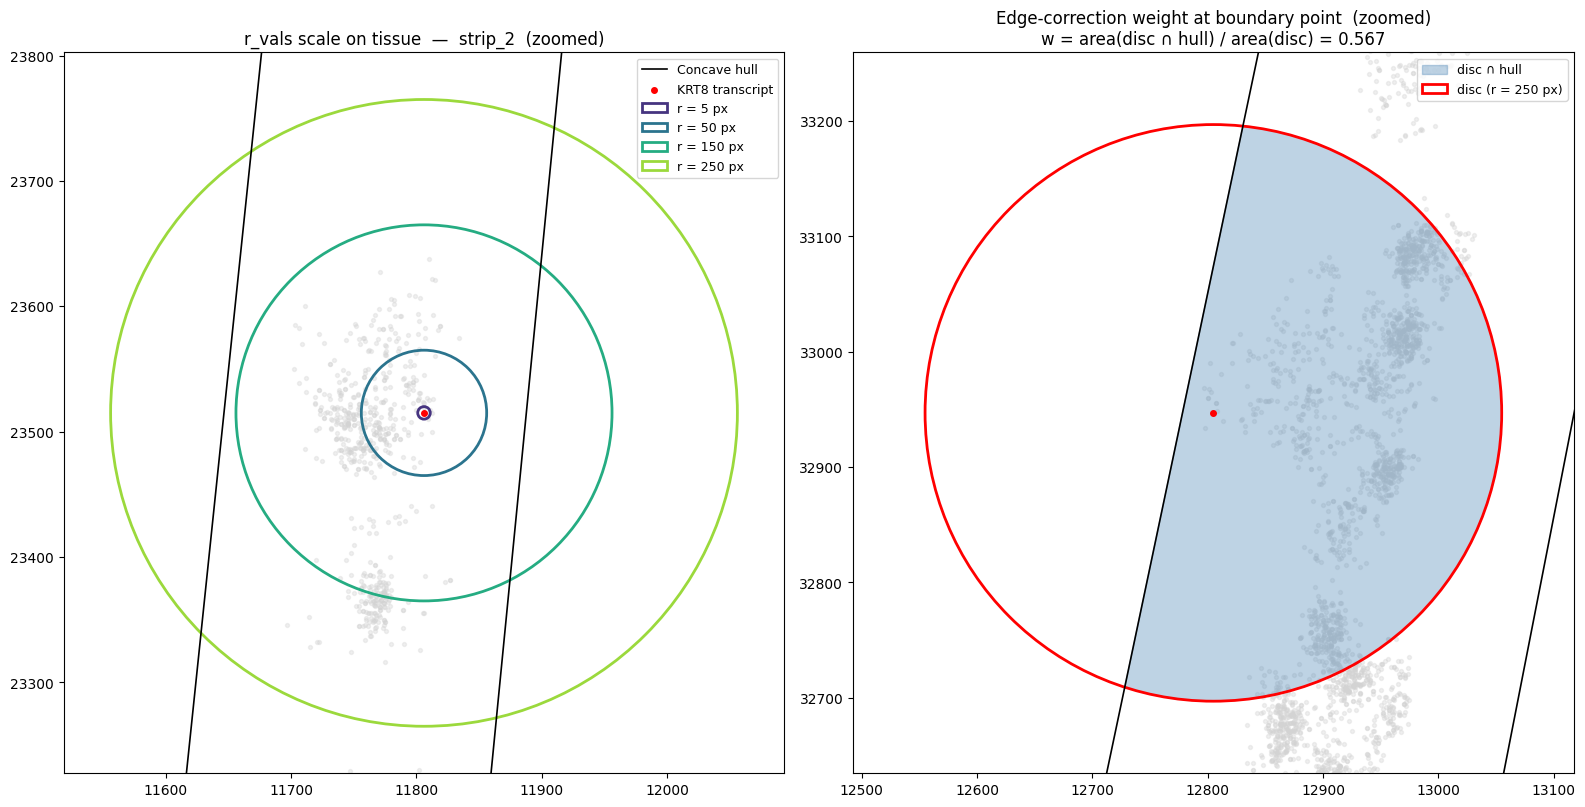

Radii shown (px):   [5, 50, 150, 250]
Interior point:     [11806. 23515.]  →  disc fully inside hull, w ≈ 1.000
Boundary point:     [12805. 32947.]  →  disc at r=250 truncated, w = 0.567


In [ ]:
from matplotlib.patches import Circle
from shapely.geometry import Point as ShPoint

VIS_STRIP = 'strip_2'
VIS_GENE  = 'KRT8'
RADII_SHOW = np.array([R_MIN, R_CC, (R_CC + R_MAX) // 2, R_MAX])

sdf    = strip_dfs[VIS_STRIP]
window = strip_windows[VIS_STRIP]
coords = get_coords(sdf, VIS_GENE)

# Interior point: gene-A transcript closest to window centroid
centroid = window.centroid
p_in_idx = np.argmin(np.hypot(coords[:, 0] - centroid.x, coords[:, 1] - centroid.y))
p_inside = coords[p_in_idx]

# Edge point: gene-A transcript closest to the hull boundary
boundary = window.boundary
p_edge_idx = np.argmin([boundary.distance(ShPoint(*p)) for p in coords])
p_edge     = coords[p_edge_idx]

cols = plt.cm.viridis(np.linspace(0.15, 0.85, len(RADII_SHOW)))
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
px, py = window.exterior.xy

# ── Panel 1: radii scale (zoomed on interior point) ───────────────────────────
ax = axes[0]
ax.scatter(sdf['x_global_px'], sdf['y_global_px'],
           s=8, alpha=0.35, c='lightgrey', rasterized=True)
ax.plot(px, py, 'k-', lw=1.2, label='Concave hull')
ax.scatter(*p_inside, s=16, c='red', zorder=5, label=f'{VIS_GENE} transcript')
for r, col in zip(RADII_SHOW, cols):
    ax.add_patch(Circle(p_inside, r, fill=False, ec=col, lw=2.0, label=f'r = {r:.0f} px'))
pad_in = R_MAX * 1.15
ax.set_xlim(p_inside[0] - pad_in, p_inside[0] + pad_in)
ax.set_ylim(p_inside[1] - pad_in, p_inside[1] + pad_in)
ax.set_aspect('equal')
ax.set_title(f'r_vals scale on tissue  -  {VIS_STRIP}  (zoomed)')
ax.legend(fontsize=9, loc='upper right')

# ── Panel 2: edge correction at boundary point (zoomed) ───────────────────────
ax = axes[1]
R_EDGE = R_MAX
disc   = ShPoint(*p_edge).buffer(R_EDGE, resolution=RESOLUTION)
inter  = disc.intersection(window)
weight = fraction_inside_hull(tuple(p_edge), R_EDGE, window, resolution=RESOLUTION)

ax.scatter(sdf['x_global_px'], sdf['y_global_px'],
           s=8, alpha=0.35, c='lightgrey', rasterized=True)
ax.plot(px, py, 'k-', lw=1.2)
polys = inter.geoms if hasattr(inter, 'geoms') else [inter]
for g in polys:
    gx, gy = g.exterior.xy
    ax.fill(gx, gy, color='steelblue', alpha=0.35)
ax.fill([], [], color='steelblue', alpha=0.35, label='disc ∩ hull')
ax.add_patch(Circle(p_edge, R_EDGE, fill=False, ec='red', lw=2.0,
                    label=f'disc (r = {R_EDGE} px)'))
ax.scatter(*p_edge, s=16, c='red', zorder=5)
pad_e = R_EDGE * 1.25
ax.set_xlim(p_edge[0] - pad_e, p_edge[0] + pad_e)
ax.set_ylim(p_edge[1] - pad_e, p_edge[1] + pad_e)
ax.set_aspect('equal')
ax.set_title(f'Edge-correction weight at boundary point  (zoomed)\n'
             f'w = area(disc ∩ hull) / area(disc) = {weight:.3f}')
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

print(f'Radii shown (px):   {RADII_SHOW.tolist()}')
print(f'Interior point:     {p_inside.round(0)}  →  disc fully inside hull, w ≈ 1.000')
print(f'Boundary point:     {p_edge.round(0)}  →  disc at r={R_EDGE} truncated, w = {weight:.3f}')

### 8c: Null model preview + L(r) interpretation key

**Left two panels**, one random label permutation of the observed `KRT8` (gene A) and `KRT18` (gene B) transcripts. Positions are held fixed; the A and B labels are pooled and reshuffled. `compute_envelope` repeats this `N_SIM` times and takes the pointwise min/max across the resulting null L(r) curves to form the envelope in section 9.

* **Left**, observed labels.
* **Middle**, one permutation drawn with the same `SEED` as the envelope (so this is literally permutation #1 of the 99 the test will run).

**Right**, how to read L(r):

* `L(r) > envelope` → **clustered** (co-localised more than chance at that radius)
* `L(r) ≈ 0`       → **independent** (consistent with the permutation null)
* `L(r) < envelope` → **dispersed** (mutual avoidance at that radius)

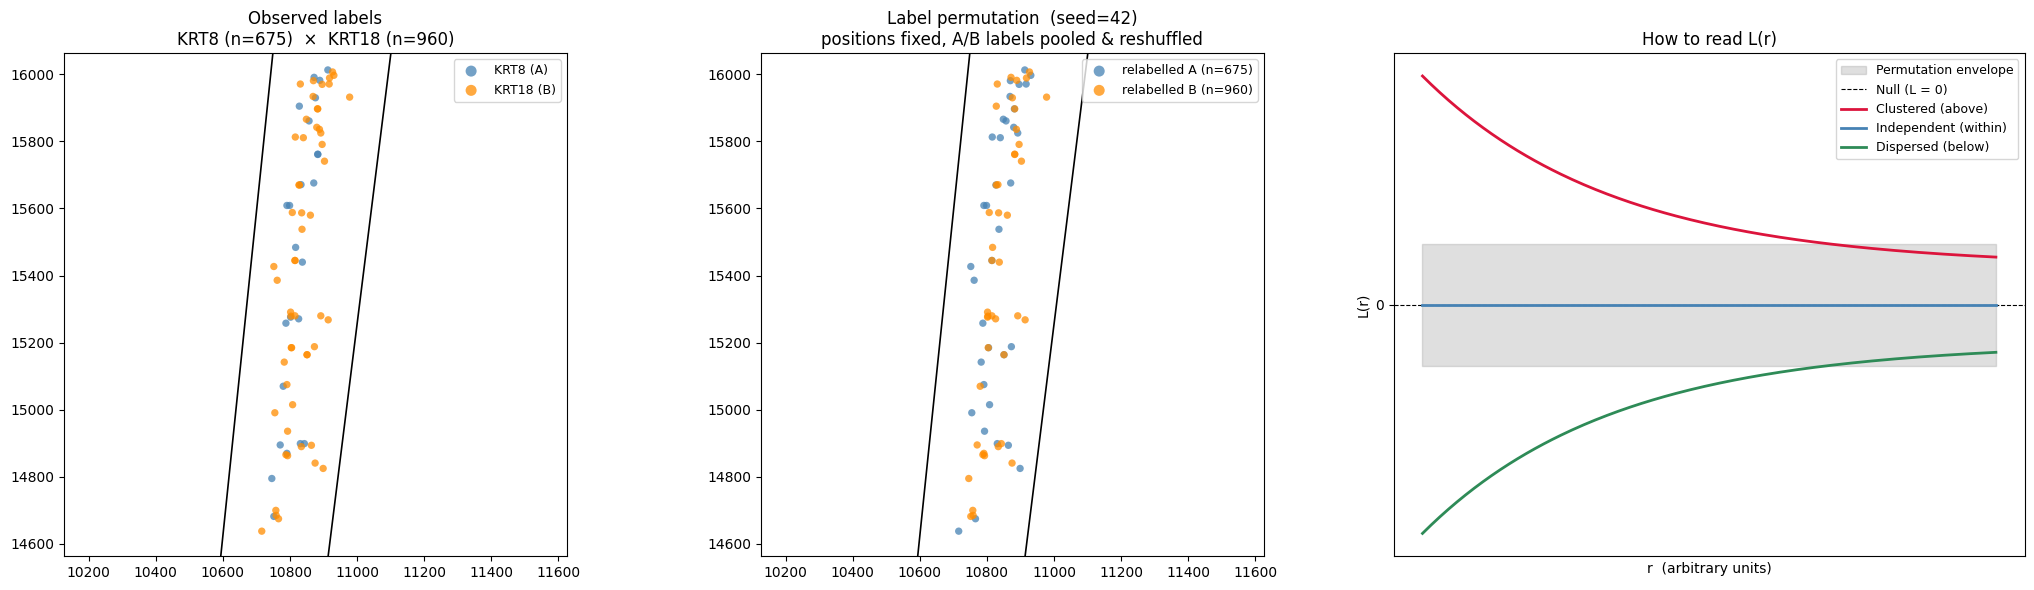

Crop: 1500×1500 px centred on densest pooled bin (10876, 15313)   —   78 points in crop
Pooled n = 1635  |  permutation matches compute_envelope(seed=42) draw #1


In [ ]:
# Match the section 9 positive control - hard-coded here because TEST_GENE_*
# is defined later; change these together if you swap the test pair.
PERM_GENE_A = 'KRT8'
PERM_GENE_B = 'KRT18'
CROP_SIZE   = 1500       # side length of the zoom crop (px)

coords_a = get_coords(strip_dfs[VIS_STRIP], PERM_GENE_A)
coords_b = get_coords(strip_dfs[VIS_STRIP], PERM_GENE_B)
n_a      = len(coords_a)

# Label permutation - mirrors compute_envelope() exactly (same SEED → same draw)
rng    = np.random.default_rng(SEED)
pooled = np.vstack([coords_a, coords_b])
idx    = rng.permutation(len(pooled))
perm_a = pooled[idx[:n_a]]
perm_b = pooled[idx[n_a:]]

# Crop centred on the densest region of the pooled points
minx, miny, maxx, maxy = window.bounds
H, _, _ = np.histogram2d(pooled[:, 0], pooled[:, 1],
                         bins=[np.linspace(minx, maxx, 40),
                               np.linspace(miny, maxy, 40)])
cx_bin, cy_bin = np.unravel_index(H.argmax(), H.shape)
crop_cx = minx + (cx_bin + 0.5) * (maxx - minx) / 40
crop_cy = miny + (cy_bin + 0.5) * (maxy - miny) / 40
half    = CROP_SIZE / 2
xlim    = (crop_cx - half, crop_cx + half)
ylim    = (crop_cy - half, crop_cy + half)

def _in_crop(pts):
    return pts[(pts[:, 0] >= xlim[0]) & (pts[:, 0] <= xlim[1]) &
               (pts[:, 1] >= ylim[0]) & (pts[:, 1] <= ylim[1])]

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
px, py = window.exterior.xy

# ── Panel 1: observed labels ──────────────────────────────────────────────────
ax = axes[0]
ax.plot(px, py, 'k-', lw=1.2)
ax.scatter(coords_a[:, 0], coords_a[:, 1], s=28, alpha=0.75,
           c='steelblue', edgecolors='none', label=f'{PERM_GENE_A} (A)')
ax.scatter(coords_b[:, 0], coords_b[:, 1], s=28, alpha=0.75,
           c='darkorange', edgecolors='none', label=f'{PERM_GENE_B} (B)')
ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_aspect('equal')
ax.set_title(f'Observed labels\n{PERM_GENE_A} (n={n_a})  ×  {PERM_GENE_B} (n={len(coords_b)})')
ax.legend(fontsize=9, loc='upper right', markerscale=1.5)

# ── Panel 2: same points, shuffled labels ─────────────────────────────────────
ax = axes[1]
ax.plot(px, py, 'k-', lw=1.2)
ax.scatter(perm_a[:, 0], perm_a[:, 1], s=28, alpha=0.75,
           c='steelblue', edgecolors='none', label=f'relabelled A (n={len(perm_a)})')
ax.scatter(perm_b[:, 0], perm_b[:, 1], s=28, alpha=0.75,
           c='darkorange', edgecolors='none', label=f'relabelled B (n={len(perm_b)})')
ax.set_xlim(xlim); ax.set_ylim(ylim); ax.set_aspect('equal')
ax.set_title(f'Label permutation  (seed={SEED})\npositions fixed, A/B labels pooled & reshuffled')
ax.legend(fontsize=9, loc='upper right', markerscale=1.5)

# ── Panel 3: L(r) interpretation schematic ────────────────────────────────────
ax     = axes[2]
r_demo = np.linspace(0, 1, 200)
env_lo = -0.08 * np.ones_like(r_demo)
env_hi =  0.08 * np.ones_like(r_demo)
ax.fill_between(r_demo, env_lo, env_hi, color='grey', alpha=0.25, label='Permutation envelope')
ax.axhline(0, color='black', lw=0.8, ls='--', label='Null (L = 0)')
ax.plot(r_demo,  0.25 * np.exp(-3 * r_demo) + 0.05, color='crimson',    lw=2, label='Clustered (above)')
ax.plot(r_demo,  0.00 * r_demo,                      color='steelblue', lw=2, label='Independent (within)')
ax.plot(r_demo, -0.25 * np.exp(-3 * r_demo) - 0.05, color='seagreen',   lw=2, label='Dispersed (below)')
ax.set_xlabel('r  (arbitrary units)')
ax.set_ylabel('L(r)')
ax.set_title('How to read L(r)')
ax.set_xticks([]); ax.set_yticks([0])
ax.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

obs_in = len(_in_crop(np.vstack([coords_a, coords_b])))
print(f'Crop: {CROP_SIZE}×{CROP_SIZE} px centred on densest pooled bin '
      f'({crop_cx:.0f}, {crop_cy:.0f})   -   {obs_in} points in crop')
print(f'Pooled n = {len(pooled)}  |  permutation matches compute_envelope(seed={SEED}) draw #1')

## 9: Test run: KRT8 × KRT18 (positive control)

Strong co-localisation expected (co-expressed epithelial keratins). Running on strip_2 with the concave hull window.

Running KRT8 × KRT18 | strip_2
  n_sim=99, r_max=250, window=concave



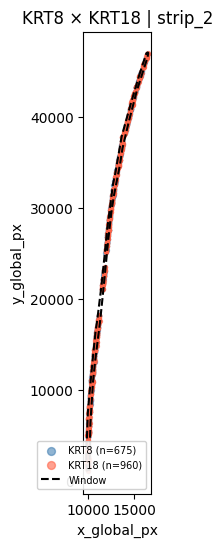

  KRT8: 675 transcripts
  KRT18: 960 transcripts
  Window: concave, area = 13691078 px²
  R_MAX = 250 px
  Observed L(r) in 1.0s
  Envelope in 90.1s


In [81]:
TEST_GENE_A = 'KRT8'
TEST_GENE_B = 'KRT18'
TEST_STRIP  = 'strip_2'

print(f'Running {TEST_GENE_A} × {TEST_GENE_B} | {TEST_STRIP}')
print(f'  n_sim={N_SIM}, r_max={R_MAX}, window={WINDOW_TYPE}')
print()

test_result = run_pair_analysis(
    strip_dfs[TEST_STRIP],
    TEST_GENE_A,
    TEST_GENE_B,
    r_vals,
    window_type=WINDOW_TYPE,
    concave_ratio=CONCAVE_RATIO,
    n_sim=N_SIM,
    seed=SEED,
    resolution=RESOLUTION,
    diagnostics=True,
    strip_name=TEST_STRIP,
)

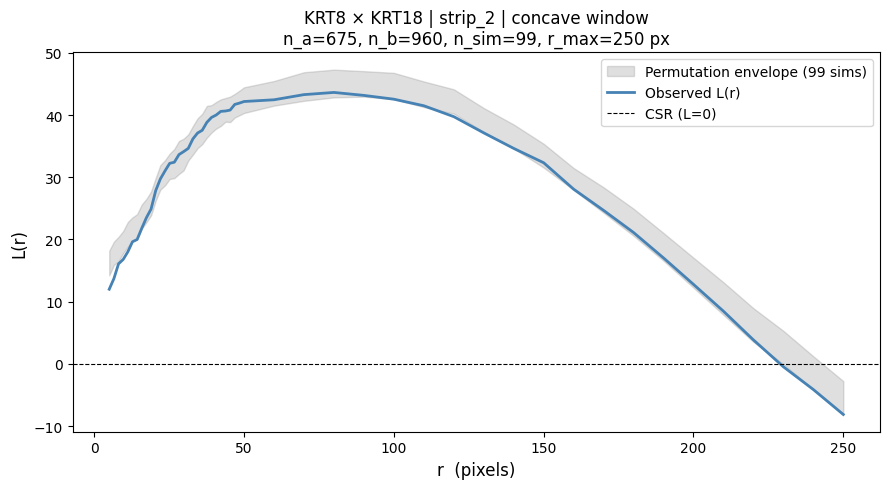

L(r) above envelope at 0/50 radii (0%) — CHECK


In [82]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(r_vals, test_result['l_lo'], test_result['l_hi'],
                alpha=0.25, color='grey', label='Permutation envelope (99 sims)')
ax.plot(r_vals, test_result['l_obs'], color='steelblue', lw=2, label='Observed L(r)')
ax.axhline(0, color='black', lw=0.8, linestyle='--', label='CSR (L=0)')
ax.set_xlabel('r  (pixels)', fontsize=12)
ax.set_ylabel('L(r)', fontsize=12)
ax.set_title(
    f'{TEST_GENE_A} × {TEST_GENE_B} | {TEST_STRIP} | {WINDOW_TYPE} window\n'
    f'n_a={test_result["n_a"]}, n_b={test_result["n_b"]}, n_sim={N_SIM}, r_max={R_MAX} px'
)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

above = (test_result['l_obs'] > test_result['l_hi']).sum()
status = 'PASS ✓' if above > N_R * 0.5 else 'CHECK'
print(f'L(r) above envelope at {above}/{N_R} radii ({100*above/N_R:.0f}%) - {status}')

## 10: HPC export

In [91]:
import os

files_to_transfer = [
    '../data/processed/s1_all_strips_cleaned.parquet',
    '../data/processed/lr_panel_index.json',
    '../data/processed/r_vals.npy',
    '../notebooks/00_functions.ipynb',
    '../scripts/batch_k_analysis.py',
]

print('=== HPC EXPORT CHECKLIST ===')
for f in files_to_transfer:
    exists = os.path.exists(f)
    status = 'OK     ' if exists else 'MISSING'
    size   = f'{os.path.getsize(f)/1e6:.1f} MB' if exists else ''
    print(f'  [{status}]  {os.path.basename(f):45s} {size}')

print('\n=== HPC RUN COMMAND ===')
print(f'''
python scripts/batch_k_analysis.py \\
    --data   data/processed/s1_all_strips_cleaned.parquet \\
    --lr     data/processed/lr_panel_index.json \\
    --fns    notebooks/00_functions.ipynb \\
    --r_vals data/processed/r_vals.npy \\
    --out    results/batch_results.parquet \\
    --window {WINDOW_TYPE} \\
    --n_sim  {N_SIM} \\
    --strips {",".join(BATCH_STRIPS)}
''')
print(f'Total jobs: {len(batch_jobs)}  |  r_vals: {N_R} points ({r_vals[0]:.1f} → {r_vals[-1]:.1f} px)')

=== HPC EXPORT CHECKLIST ===
  [OK     ]  s1_all_strips_cleaned.parquet                 20.2 MB
  [OK     ]  lr_panel_index.json                           0.0 MB
  [OK     ]  r_vals.npy                                    0.0 MB
  [OK     ]  00_functions.ipynb                            0.1 MB
  [OK     ]  batch_k_analysis.py                           0.0 MB

=== HPC RUN COMMAND ===

python scripts/batch_k_analysis.py \
    --data   data/processed/s1_all_strips_cleaned.parquet \
    --lr     data/processed/lr_panel_index.json \
    --fns    notebooks/00_functions.ipynb \
    --r_vals data/processed/r_vals.npy \
    --out    results/batch_results.parquet \
    --window concave \
    --n_sim  99 \
    --strips strip_1,strip_2,strip_3

Total jobs: 438  |  r_vals: 50 points (5.0 → 250.0 px)


In [84]:
import os
os.makedirs('../results', exist_ok=True)

manifest = pd.DataFrame(batch_jobs, columns=['ligand', 'receptor', 'strip'])
manifest.to_csv('../results/hpc_job_manifest.csv', index=False)
print(f'Job manifest saved: results/hpc_job_manifest.csv ({len(manifest)} rows)')
manifest.head(10)

Job manifest saved: results/hpc_job_manifest.csv (438 rows)


,ligand,receptor,strip
0,DLL1,NOTCH1,strip_1
1,DLL1,NOTCH1,strip_2
2,DLL1,NOTCH1,strip_3
3,IGF1,IGF1R,strip_1
4,IGF1,IGF1R,strip_2
5,IGF1,IGF1R,strip_3
6,JAG1,NOTCH1,strip_1
7,JAG1,NOTCH1,strip_2
8,JAG1,NOTCH1,strip_3
9,CXCL16,CXCR6,strip_1
